In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [6]:
url= "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df= pd.read_csv(url, sep= '\t', header=None, names=['lable','message'])
df

,lable,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
df['lable']=df['lable'].map({'ham':0, 'spam':1})

In [8]:
df

,lable,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [9]:
x_train, x_test, y_train, y_test= train_test_split(df['message'], df['lable'], test_size=0.30)

In [10]:
vectorize= CountVectorizer()

'''

vectorizer.fit_transform(x_train)
fit: Learns the vocabulary from the training data — i.e., it sees all unique words and assigns them a number (index).

transform: Converts each message in x_train into a numeric vector using that vocabulary.

Together, fit_transform means:
➤ "Learn the words from training data and convert the training messages into vectors."



 vectorizer.transform(x_test)
This does NOT re-learn the vocabulary.

It only uses the same word-index mapping learned from training data to convert x_test into vectors.

🧠 Why not fit_transform(x_test)?

If you used fit_transform on x_test, it would learn a new vocabulary, which:

May include words not seen in training

Breaks the ML principle: “Do not learn from test data!”

Leads to mismatched features between train and test sets
'''
x_train_vec = vectorize.fit_transform(x_train)
x_test_vec = vectorize.transform(x_test)

In [11]:
x_train_vec

<3900x7164 sparse matrix of type '<class 'numpy.int64'>'
	with 51565 stored elements in Compressed Sparse Row format>

In [12]:
model= LogisticRegression()
model.fit(x_train_vec,y_train)

LogisticRegression()

In [13]:
y_pred= model.predict(x_test_vec)

In [14]:
accuracy_score(y_test,y_pred)*100

98.50478468899522

In [15]:
print("classification report: \n",classification_report(y_test,y_pred))

classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1453
           1       0.98      0.90      0.94       219

    accuracy                           0.99      1672
   macro avg       0.98      0.95      0.97      1672
weighted avg       0.98      0.99      0.98      1672



<Axes: >

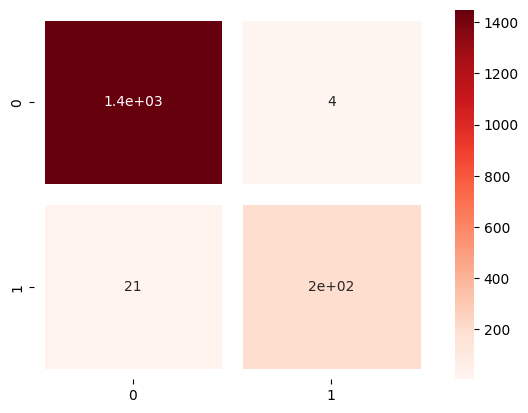

In [16]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(data=cm,annot=True,linewidths=15, cmap='Reds')

In [17]:
my_email=["""Hi Pratheek poojary,

Tech is evolving fast—are you ready to evolve with it? Get the skills, degree, and confidence to shape your future in tech.

The JAIN (Deemed-to-be University’s) Online MCA Degree is for freshers and early professionals ready to launch their IT careers with confidence.

Backed by a top Indian institution, this degree offers career-ready skills, industry-aligned learning, and a name that enhances your resume.
"""]
my_email_vec = vectorize.transform(my_email)
prediction = model.predict(my_email_vec)
print(prediction)

[1]
